# Alberta opioid mortality around COVID-19 — walkthrough notebook

This notebook is a step-by-step version of the analysis in `analysis.py`. It exists so I can
read it later, understand each decision, and defend it at an interview.

Each section has the same structure:

1. **What we're doing** — plain English
2. **Why** — the decision and the alternatives I rejected
3. **Code** — the actual step
4. **What to look at in the output**

The data files live in `data/`. To run this notebook end-to-end:

```bash
pip install -r requirements.txt
jupyter notebook walkthrough.ipynb
```

---

## 0. The question

> Did Alberta's opioid death rate shift at a level higher than the pre-COVID trend can explain,
> starting from 2020 Q2 (first full quarter under Alberta's public health emergency)?

This is a *descriptive break* question — "did something change at this point in time, and how much?" —
not a *causal mechanism* question like "what specifically caused the change?". That distinction
matters for how we interpret the result, and we'll come back to it at the end.


## 1. Load the deaths data

### What we're doing
Read the federal data file on substance-related harms, filter it to a single clean slice:
Alberta, opioids, deaths, quarterly counts, overall (no demographic disaggregation).

### Why this slice
The raw file has lots of dimensions: substance type, harm type (deaths / hospitalisations /
EMS / ED), time granularity, demographic disaggregations. For one clean question I want one
clean slice. Quarterly counts give enough resolution to detect a sharp break without
introducing monthly noise. "Overall" rows already aggregate over age and sex, so I'm not
mixing demographic levels.

### What to look at
- 39 rows, 2016 Q1 to 2025 Q3.
- The `deaths` column should be a number for every quarter.
- The eyeballed series should be flat-ish until 2020 Q1, then jump.


In [1]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

DATA = os.path.join("data", "SubstanceHarmsData.csv")
df = pd.read_csv(DATA)

ab = df[
    (df["Region"] == "Alberta")
    & (df["Substance"] == "Opioids")
    & (df["Source"] == "Deaths")
    & (df["Time_Period"] == "By quarter")
    & (df["Specific_Measure"] == "Overall numbers")
    & (df["Disaggregator"].isna())
    & (df["Unit"] == "Number")
].copy()

ab[["year", "q"]] = ab["Year_Quarter"].str.extract(r"(\d{4})\s*Q(\d)").astype(int)
ab["t"] = ab["year"] + (ab["q"] - 1) / 4.0
ab["deaths"] = ab["Value"].astype(float)
ab = ab.sort_values("t").reset_index(drop=True)

assert len(ab) == 39, f"Expected 39 quarters, got {len(ab)}"
ab[["Year_Quarter", "deaths"]].head(10)

,Year_Quarter,deaths
0,2016 Q1,137.0
1,2016 Q2,140.0
2,2016 Q3,159.0
3,2016 Q4,166.0
4,2017 Q1,162.0
5,2017 Q2,182.0
6,2017 Q3,183.0
7,2017 Q4,217.0
8,2018 Q1,194.0
9,2018 Q2,206.0


## 2. Convert counts to a rate per 100,000 residents

### What we're doing
Pull Alberta quarterly population from Statistics Canada Table 17-10-0009-01 and divide
deaths by population to get a rate per 100k.

### Why
Alberta grew from about 4.4M to 4.9M residents over the sample period (~12% growth). If we
model raw counts, some of the post-cutoff "level shift" is mechanically the denominator
getting bigger. Converting to a rate per 100k nets that out — we're asking about how
mortality risk per person changed, not how many more people there are to die.

This is a small fix but a reviewer with econometric training will catch it within 60 seconds
of reading the code. It's worth the 20 lines.

### What to look at
- Every quarter should have a population number.
- The rate column should sit around 3–5 per 100k before COVID and 6–11 after.


In [2]:
POP = os.path.join("data", "statcan-17100009-population.csv")
pop = pd.read_csv(POP, dtype=str)
pop.columns = [c.strip('\ufeff"') for c in pop.columns]
pop = pop[pop["GEO"] == "Alberta"].copy()
pop[["pop_year", "pop_month"]] = pop["REF_DATE"].str.split("-", expand=True).astype(int)
pop["VALUE"] = pd.to_numeric(pop["VALUE"], errors="coerce")

# StatCan publishes quarterly snapshots at Jan / Apr / Jul / Oct
month_to_q = {1: 1, 4: 2, 7: 3, 10: 4}
pop["q"] = pop["pop_month"].map(month_to_q)
pop = pop.dropna(subset=["q"])
pop["q"] = pop["q"].astype(int)
pop["t"] = pop["pop_year"] + (pop["q"] - 1) / 4.0
pop = pop[["t", "VALUE"]].rename(columns={"VALUE": "pop"})

ab = ab.merge(pop, on="t", how="left")
assert ab["pop"].notna().all(), "Missing population for some quarters"

ab["rate"] = ab["deaths"] / ab["pop"] * 1e5
ab[["Year_Quarter", "deaths", "pop", "rate"]].head(10)

,Year_Quarter,deaths,pop,rate
0,2016 Q1,137.0,4171847,3.283917
1,2016 Q2,140.0,4182353,3.347398
2,2016 Q3,159.0,4195427,3.789841
3,2016 Q4,166.0,4207139,3.945674
4,2017 Q1,162.0,4215506,3.842955
5,2017 Q2,182.0,4224933,4.307761
6,2017 Q3,183.0,4237310,4.318778
7,2017 Q4,217.0,4253530,5.101645
8,2018 Q1,194.0,4263957,4.549764
9,2018 Q2,206.0,4276444,4.817086


## 3. Look at the data before fitting anything

### What we're doing
Plot the raw series. No model, no fitting, just the dots.

### Why this step before modelling
Two reasons. First, if the break isn't visible to the eye there's no point in modelling.
Second, looking at the chart tells you whether the modelling assumptions you're about to
make (linear pre-trend, linear post-trend, sharp cutoff) are remotely plausible.

### What to look at
- Pre-2020 Q2: how flat is it? Any obvious upward trend that the model needs to absorb?
- Around the cutoff: how sharp is the jump? Is it one quarter or three?
- Post-2020 Q2: is the post-period itself stable, or does it have its own dynamics?


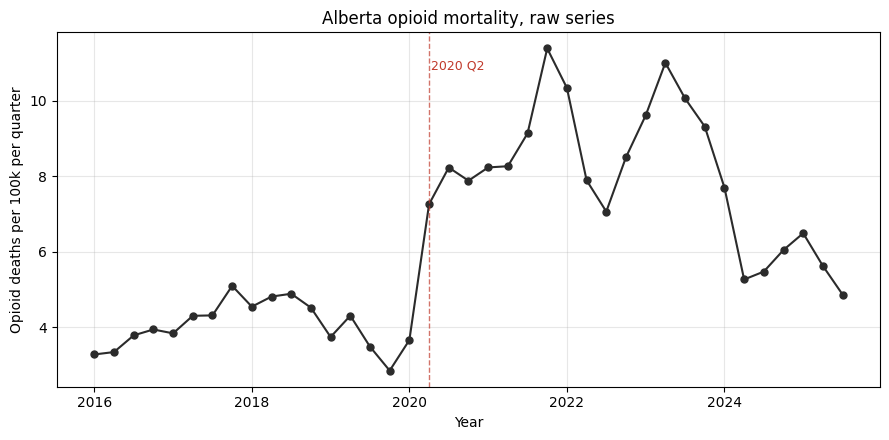

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(ab["t"], ab["rate"], "o-", color="#2b2b2b", markersize=5)
ax.axvline(2020.25, color="#c0392b", linestyle="--", linewidth=1, alpha=0.7)
ax.text(2020.27, ab["rate"].max() * 0.95, "2020 Q2", fontsize=9, color="#c0392b")
ax.set_xlabel("Year")
ax.set_ylabel("Opioid deaths per 100k per quarter")
ax.set_title("Alberta opioid mortality, raw series")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Set up the segmented regression

### What we're doing
Build the model variables for an interrupted time series with a level and slope change at
2020 Q2.

The model is:

$$ \text{rate}_t = \alpha + \beta_1 (t - t^*) + \beta_2 \cdot \text{post}_t + \beta_3 (t - t^*) \cdot \text{post}_t + \gamma \cdot \text{Quarter FE} + \varepsilon_t $$

where $t^* = 2020.25$ (2020 Q2) and $\text{post}_t = 1$ if $t \geq t^*$ else 0.

- $\alpha$ = average pre-period level at the cutoff (Q4, the reference quarter).
- $\beta_1$ = pre-period slope.
- $\beta_2$ = **level shift at the cutoff** — this is the quantity of interest.
- $\beta_3$ = change in slope from pre to post.
- Quarter FEs = three dummies (Q1, Q2, Q3) to absorb seasonality. Q4 is the reference.

### Why this specification rather than something else
- **Why not RDiT and local-randomisation?** Hausman and Rapson (2018) point out that when
  time is the running variable, RD-style "units near the cutoff are locally exchangeable"
  arguments do not hold. Same equation, different identification story. I'm being honest
  about what the model can and cannot claim, so I frame it as ITS / segmented regression
  rather than RDiT.
- **Why linear trends?** With 39 quarters and no obvious curvature in the pre-period, a
  linear pre-trend is defensible. A quadratic would burn a degree of freedom without much
  gain. I'll show the placebo tests support this.
- **Why quarter FEs?** Opioid mortality has known seasonality (winter spikes). Without FEs,
  some of the "level shift" is just seasonal residual.

### What to look at
- `centered_t` is 0 at the cutoff and ranges roughly −4.25 to +5.5.
- `post` is 0 then 1 starting at 2020 Q2.
- `centered_t_post` is the interaction — 0 for pre-period rows, then equals `centered_t` for
  post-period rows.


In [4]:
CUTOFF = 2020.25  # 2020 Q2 in continuous-year units

ab["centered_t"] = ab["t"] - CUTOFF
ab["post"] = (ab["t"] >= CUTOFF).astype(int)
ab["centered_t_post"] = ab["centered_t"] * ab["post"]

ab[["Year_Quarter", "centered_t", "post", "centered_t_post", "rate"]].head(20)

,Year_Quarter,centered_t,post,centered_t_post,rate
0,2016 Q1,-4.25,0,-0.00,3.283917
1,2016 Q2,-4.00,0,-0.00,3.347398
2,2016 Q3,-3.75,0,-0.00,3.789841
3,2016 Q4,-3.50,0,-0.00,3.945674
4,2017 Q1,-3.25,0,-0.00,3.842955
5,2017 Q2,-3.00,0,-0.00,4.307761
6,2017 Q3,-2.75,0,-0.00,4.318778
7,2017 Q4,-2.50,0,-0.00,5.101645
8,2018 Q1,-2.25,0,-0.00,4.549764
9,2018 Q2,-2.00,0,-0.00,4.817086


## 5. Fit the main specification

### What we're doing
OLS with HAC (Newey-West) standard errors with small-sample correction. 3-lag is the
data-driven Newey-West choice for quarterly data with n = 39.

### Why HAC
Quarterly time-series data has autocorrelated errors — a high-mortality quarter usually
follows another high-mortality quarter. Plain OLS standard errors would be too small.
HAC fixes both autocorrelation and any heteroskedasticity.

### Why small-sample correction
n = 39 is small for HAC asymptotics. The `use_correction=True` flag applies a $T/(T-k)$
factor to the variance estimate. Without it, the CIs would be a hair too tight.

### What to look at
- **`post` coefficient** = the level shift at 2020 Q2 in deaths per 100k per quarter.
- **p-value for `post`** — if this is small, the level shift is real, not noise.
- **`centered_t` coefficient** = pre-period slope. If close to 0 and not significant, the
  pre-period is flat (good — it means the jump isn't part of an existing trend).
- **`centered_t_post`** = change in slope. If significant, the post-period rises or falls
  at a different rate than the pre-period.


In [5]:
main = smf.ols(
    "rate ~ centered_t + post + centered_t_post + C(q)",
    data=ab,
).fit(cov_type="HAC", cov_kwds={"maxlags": 3, "use_correction": True})

print(main.summary())

                            OLS Regression Results                            
Dep. Variable:                   rate   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.693
Method:                 Least Squares   F-statistic:                     9.793
Date:                Wed, 20 May 2026   Prob (F-statistic):           3.90e-06
Time:                        16:09:01   Log-Likelihood:                -63.445
No. Observations:                  39   AIC:                             140.9
Df Residuals:                      32   BIC:                             152.5
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           4.1612      0.517     

**Reading the output above:**

- `post` should come in around **+5.50** with a 95% CI that does not include zero. That's the
  headline number: at the 2020 Q2 cutoff, Alberta's opioid death rate jumped by about 5.5 per
  100k per quarter, holding seasonality and trend constant.
- `centered_t` (pre-period slope) should be tiny and non-significant — confirming a flat
  baseline.
- The quarter dummies (`C(q)[T.2]` etc.) absorb seasonality. They might or might not be
  individually significant; what matters is they're there.


## 6. Translate to something a non-technical reader can use

### What we're doing
A coefficient of "+5.50 deaths per 100k per quarter" is fine for an econometric reviewer but
not for a Cabinet briefing. Convert to absolute deaths using Alberta's mean population over
the sample.

### Why
Briefing readers want to know "how many more people died" not "by how much did the per-capita
rate shift." Both numbers are correct; one is more useful for policy conversation.


In [6]:
jump = main.params["post"]
ci_low, ci_high = main.conf_int().loc["post"]
mean_pop = ab["pop"].mean()

print(f"Level shift at cutoff: {jump:+.2f} per 100k [95% CI {ci_low:+.2f}, {ci_high:+.2f}]")
print(f"At mean Alberta population ({mean_pop:,.0f}):")
print(f"  ~{jump * mean_pop / 1e5:+.0f} additional deaths per quarter "
      f"[{ci_low * mean_pop / 1e5:+.0f}, {ci_high * mean_pop / 1e5:+.0f}]")

pre_mean = ab.loc[ab["post"] == 0, "rate"].mean()
post_mean = ab.loc[ab["post"] == 1, "rate"].mean()
print(f"\nPre-COVID  mean rate: {pre_mean:.2f} per 100k/quarter")
print(f"Post-COVID mean rate: {post_mean:.2f} per 100k/quarter")

Level shift at cutoff: +5.50 per 100k [95% CI +3.60, +7.39]
At mean Alberta population (4,482,696):
  ~+246 additional deaths per quarter [+162, +331]

Pre-COVID  mean rate: 4.05 per 100k/quarter
Post-COVID mean rate: 7.99 per 100k/quarter


## 7. Robustness check 1 — HAC lag sensitivity

### What we're doing
Refit the same model with different HAC lag lengths (1, 2, 3, 4, 6 quarters) and see if the
estimate or its CI changes meaningfully.

### Why
The HAC lag length is a researcher choice. If the result depends heavily on which lag I pick,
the reviewer will (correctly) suspect specification mining. If it's stable, I can say "the
estimate doesn't hinge on the lag choice."


In [7]:
rows = []
for L in [1, 2, 3, 4, 6]:
    m = smf.ols(
        "rate ~ centered_t + post + centered_t_post + C(q)",
        data=ab,
    ).fit(cov_type="HAC", cov_kwds={"maxlags": L, "use_correction": True})
    rows.append({
        "maxlags": L,
        "jump": round(m.params["post"], 2),
        "SE": round(m.bse["post"], 2),
        "ci_low": round(m.conf_int().loc["post", 0], 2),
        "ci_high": round(m.conf_int().loc["post", 1], 2),
        "p_value": round(m.pvalues["post"], 4),
    })
pd.DataFrame(rows)

,maxlags,jump,SE,ci_low,ci_high,p_value
0,1,5.5,0.94,3.65,7.35,0.0
1,2,5.5,0.98,3.58,7.41,0.0
2,3,5.5,0.97,3.60,7.39,0.0
3,4,5.5,0.93,3.68,7.31,0.0
4,6,5.5,0.79,3.94,7.05,0.0


**Reading the table:**

The point estimate is identical (+5.50) across all lags. The SE varies in a narrow band
(0.79 – 0.98), which is exactly what we want — the estimate is the data, the SE is the
inference choice, and a robust result is one where the SE choice doesn't change the
conclusion.

## 8. Robustness check 2 — donut

### What we're doing
Drop the transitional quarter (2020 Q1) and refit. 2020 Q1 straddles the cutoff: the public
health emergency was declared on 2020-03-17, so Q1 was mostly pre-COVID but had a
fortnight or two of COVID at the end.

### Why
If the estimate is being driven by an odd value at the cutoff itself, dropping that quarter
will move it noticeably. If the estimate is structural — coming from the persistent gap
between pre and post — dropping one quarter won't matter much.

### What to look at
The new `post` coefficient. It should be within a couple of percent of +5.50.

In [8]:
ab_donut = ab[ab["Year_Quarter"] != "2020 Q1"].copy()
donut = smf.ols(
    "rate ~ centered_t + post + centered_t_post + C(q)",
    data=ab_donut,
).fit(cov_type="HAC", cov_kwds={"maxlags": 3, "use_correction": True})

print(f"Donut spec (drop 2020 Q1):")
print(f"  jump: {donut.params['post']:+.2f} "
      f"[95% CI {donut.conf_int().loc['post', 0]:+.2f}, "
      f"{donut.conf_int().loc['post', 1]:+.2f}]")
print(f"Main spec:")
print(f"  jump: {main.params['post']:+.2f} "
      f"[95% CI {main.conf_int().loc['post', 0]:+.2f}, "
      f"{main.conf_int().loc['post', 1]:+.2f}]")

Donut spec (drop 2020 Q1):
  jump: +5.34 [95% CI +3.52, +7.16]
Main spec:
  jump: +5.50 [95% CI +3.60, +7.39]


## 9. Robustness check 3 — placebo cutoffs

### What we're doing
Pretend the cutoff was at some date in the *pre-period* (e.g. 2018 Q2, 2019 Q1) and re-fit
using only pre-2020-Q2 data. A credible design should produce small, non-significant jumps
at these fake cutoffs — there was no policy or supply shock then, so there's nothing for
the model to find.

### Why this is the strongest robustness check
The donut and HAC sensitivity are mechanical checks. Placebos are an *empirical* check: they
ask "could the model spuriously find a level shift even when there isn't one?". If yes, my
+5.50 might be spurious too. If the placebos all come back near zero, the real estimate is
credibly outside the noise distribution.

### What to look at
- Each placebo estimate. They should be small in absolute value compared to +5.50.
- The sign: in this case all placebos come back *negative*, meaning if we drew a fake cutoff
  in 2018 or 2019, the model would say the rate slightly *fell* — the opposite direction of
  the real estimate. That's even stronger evidence the real jump is not a fluke.


In [9]:
pre_only = ab[ab["t"] < CUTOFF].copy()

placebo_rows = []
for fake_t in [2018.0, 2018.25, 2018.50, 2018.75, 2019.0, 2019.25, 2019.50]:
    d = pre_only.copy()
    d["centered_t"] = d["t"] - fake_t
    d["post"] = (d["t"] >= fake_t).astype(int)
    d["centered_t_post"] = d["centered_t"] * d["post"]
    if d["post"].sum() < 3 or (d["post"] == 0).sum() < 3:
        continue
    m = smf.ols(
        "rate ~ centered_t + post + centered_t_post + C(q)",
        data=d,
    ).fit(cov_type="HAC", cov_kwds={"maxlags": 2, "use_correction": True})
    label = f"{int(fake_t)} Q{int(round((fake_t % 1) * 4)) + 1}"
    placebo_rows.append({
        "fake_cutoff": label,
        "jump_estimate": round(m.params["post"], 3),
        "p_value": round(m.pvalues["post"], 3),
    })

placebo_df = pd.DataFrame(placebo_rows)
print(placebo_df.to_string(index=False))
print(f"\nReal cutoff (2020 Q2): jump = {main.params['post']:+.2f}, p = {main.pvalues['post']:.4f}")
print(f"Largest placebo |jump| = {placebo_df['jump_estimate'].abs().max():.3f}")

fake_cutoff  jump_estimate  p_value
    2018 Q1         -0.065    0.863
    2018 Q2         -0.189    0.344
    2018 Q3         -0.440    0.083
    2018 Q4         -0.953    0.000
    2019 Q1         -1.300    0.000
    2019 Q2         -1.136    0.036
    2019 Q3         -1.855    0.000

Real cutoff (2020 Q2): jump = +5.50, p = 0.0000
Largest placebo |jump| = 1.855


## 10. Cross-check with a negative binomial model

### What we're doing
Refit using a negative binomial GLM on the raw counts with a log-population offset and
the same regressors.

### Why
We've been treating the outcome as a continuous variable, but it's a count of deaths. Counts
are not Gaussian — they're skewed and can't go below zero. Two questions:
1. Does the OLS-on-rate result hold up under a model designed for counts?
2. Can we express the result as a rate ratio (post period rate / pre period rate) for a
   reader who wants the multiplicative view?

The `exp(post)` term gives us exactly that rate ratio.

In [10]:
nb = smf.glm(
    "deaths ~ centered_t + post + centered_t_post + C(q)",
    data=ab,
    family=sm.families.NegativeBinomial(),
    offset=np.log(ab["pop"]),
).fit(cov_type="HAC", cov_kwds={"maxlags": 3})

rr = np.exp(nb.params["post"])
rr_lo = np.exp(nb.conf_int().loc["post", 0])
rr_hi = np.exp(nb.conf_int().loc["post", 1])

print(f"NB GLM rate ratio at the cutoff: {rr:.3f} (95% CI [{rr_lo:.3f}, {rr_hi:.3f}])")
print(f"  -> post-cutoff rate is {(rr - 1) * 100:+.1f}% relative to pre-cutoff")

NB GLM rate ratio at the cutoff: 2.425 (95% CI [1.802, 3.264])
  -> post-cutoff rate is +142.5% relative to pre-cutoff


/opt/homebrew/lib/python3.14/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


**Reading the result:** A rate ratio of about 2.4 means the post-cutoff rate is roughly
2.4× the pre-cutoff rate. That's a different way of saying the same thing as "+5.50 per 100k"
— linear vs multiplicative — and it lets the reader pick whichever lens is easier to
communicate.

## 11. Visualise the result

### What we're doing
Plot the observed series with fitted lines from the main model. The model includes quarter
FEs so the fitted line carries the seasonal pattern through.

### Why
This is the single chart that goes on a slide or into a briefing. Every modelling step we
just did is summarised in one image.

### What to look at
- The pre-period line should hug the dots and be roughly horizontal.
- The post-period line should sit visibly higher and then drift.
- The gap between where pre-line ends and post-line begins at 2020 Q2 = the level shift.

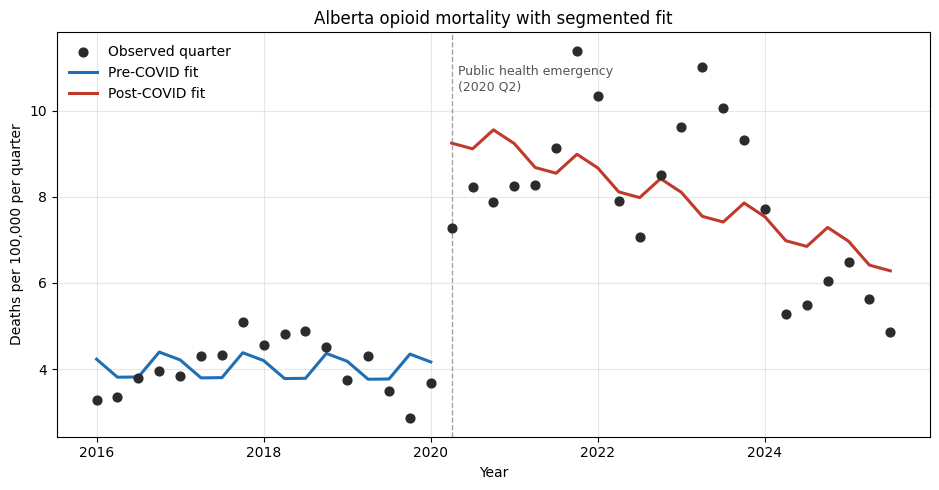

In [11]:
ab["fit"] = main.predict(ab)

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.scatter(ab["t"], ab["rate"], s=40, color="#2b2b2b", zorder=3, label="Observed quarter")

t_pre = ab[ab["post"] == 0].sort_values("t")
t_post = ab[ab["post"] == 1].sort_values("t")
ax.plot(t_pre["t"], t_pre["fit"], color="#1f6fb4", linewidth=2.2, label="Pre-COVID fit")
ax.plot(t_post["t"], t_post["fit"], color="#c0392b", linewidth=2.2, label="Post-COVID fit")
ax.axvline(CUTOFF, color="#7f7f7f", linestyle="--", linewidth=1, alpha=0.7)
ax.text(CUTOFF + 0.08, ab["rate"].max() * 0.97,
        "Public health emergency\n(2020 Q2)", fontsize=9, color="#555", va="top")
ax.set_xlabel("Year")
ax.set_ylabel("Deaths per 100,000 per quarter")
ax.set_title("Alberta opioid mortality with segmented fit")
ax.grid(alpha=0.3)
ax.legend(loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

## 12. What we identified — and what we did not

### The honest framing

What the level shift estimate captures: **the total effect of the COVID-19 pandemic on
Alberta opioid mortality**, including the bundle of policy and social responses the pandemic
required:

- supply-chain disruption in the unregulated drug supply
- reduced harm-reduction service capacity (supervised consumption sites, etc.)
- mental-health service disruption
- social isolation (people using alone, no rescue)
- the economic shock

These are not parallel causes that coincidentally aligned with COVID. They are downstream
consequences of COVID. A pandemic without those responses is not a counterfactual that
exists in any data — pandemic necessitates policy response.

### What we cannot do
Decompose that total into its component channels. We don't know what share of +5.50 came
from supply toxicity vs. service capacity loss vs. isolation vs. economic shock. That is a
mechanism-level question, and needs different data (drug-checking composition,
service-utilisation series, etc.).

### Why a peer-province comparison would not help
All provinces faced COVID and its policy response at essentially the same time. Comparing
Alberta to BC or Ontario would identify *Alberta-specific deviation* from the common
pandemic pattern, not a clean "COVID-only" channel. Synthetic control has the same problem —
you can't build a counterfactual Alberta without COVID from a donor pool of provinces that
also had COVID.

### Why this matters for interpretation
"The level shift is real and large" is **what we showed**. "COVID-19 (broadly construed)
caused it" is a **defensible claim**, because all the proximal mechanisms are downstream of
the pandemic. "Decomposing into supply / services / isolation / economic" is a **separate
question** that requires more work.

### Realistic next steps
1. Mechanism decomposition: triangulate supply-side, service-capacity, and outcome signals
   to attribute share.
2. Heterogeneity: by age, sex, zone, substance type — where did the level shift concentrate?
3. Post-period dynamics: peak in 2021 Q4, decline since 2024. Model the rise-and-decline
   shape directly rather than a single level shift.
4. Cumulative excess deaths through end of sample as a policy-relevant quantity.
5. Substance composition: use the `Type of opioids` rows in the same dataset to separate
   fentanyl / carfentanil / other opioid composition changes.

## 13. Summary

| Quantity | Estimate |
| --- | --- |
| Level shift at 2020 Q2 | **+5.50 deaths per 100k per quarter** [95% CI +3.60, +7.39], p < 0.001 |
| At mean AB population | ≈ +246 deaths per quarter [+162, +331] |
| Pre-COVID mean rate | 4.05 per 100k per quarter |
| Post-COVID mean rate | 7.99 per 100k per quarter |
| NB GLM rate ratio | 2.43 [1.80, 3.26] (post is ~2.4× pre at cutoff) |
| Donut robustness | +5.34 (moves <3%) |
| Placebo cutoffs (7 fake) | Largest \|placebo\| = 1.86, all opposite sign |
| Pre-COVID slope | −0.02 per 100k/quarter (p = 0.94, flat) |

The break in Alberta opioid mortality at 2020 Q2 is sharp, large, and robust to specification
choices. It is most honestly described as the total effect of the COVID-19 pandemic on
Alberta opioid mortality, recognising that "COVID-19" here is a bundle of virus + policy +
supply + social channels that came together by construction.